In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 97.3 MB/s eta 0:00:00


In [ ]:
# %load_ext autoreload
# %autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchsde
import numpy as np
import pandas as pd
from torchdyn.core import NeuralODE
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models.unet import UNetModel

savedir = "models/mnist"
os.makedirs(savedir, exist_ok=True)

In [ ]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 128
n_epochs = 7

# trainset = datasets.MNIST(
#     "../data",
#     train=True,
#     download=True,
#     transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),
# )

# train_loader = torch.utils.data.DataLoader(
#     trainset, batch_size=batch_size, shuffle=True, drop_last=True
# )

In [ ]:
class CustomMnistDataset(torch.utils.data.Dataset):
    """
    Reads the MNIST data from csv file given file path.
    """
    def __init__(self, csv_path, num_datapoints = None):
        super(CustomMnistDataset, self).__init__()

        self.df = pd.read_csv(csv_path)

        # Will be useful later while evaluating
        if num_datapoints is not None:
            self.df = self.df.iloc[0:num_datapoints]

    def __len__(self):
        return len(self.df)

    def  __getitem__(self, index):
        # Read
        img = self.df.iloc[index].filter(regex='pixel').values
        img =  np.reshape(img, (28, 28)).astype(np.uint8)

        # Convert to Tensor
        img_tensor = transforms.ToTensor()(img) # [0, 1]
        # img_tensor = 2*img_tensor - 1 # [-1, 1]
        img_tensor = transforms.Normalize((0.5,), (0.5,))(img_tensor)

        return img_tensor

In [ ]:
# !unzip /content/drive/MyDrive/cursach-hse/mnist_data/train.csv.zip
# !unzip /content/drive/MyDrive/cursach-hse/mnist_data/test.csv.zip

In [ ]:
train_csv_path = '/content/train.csv'
test_csv_path = '/content/test.csv'

trainset = CustomMnistDataset(train_csv_path)
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)

In [ ]:
sigma = 0.0
model = UNetModel(dim=(1, 28, 28), num_channels=32, num_res_blocks=2).to(device)
optimizer = torch.optim.Adam(model.parameters())
# FM = ConditionalFlowMatcher(sigma=sigma)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [ ]:
for epoch in range(n_epochs):
    running_loss = 0
    for i, data in tqdm(enumerate(train_loader)):
        optimizer.zero_grad()
        x1 = data.to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt)
        loss = torch.mean((vt - ut) ** 2)
        running_loss += loss.item()
        loss.backward()
        optimizer.step()
    running_loss /= (i+1)
    print(f"epoch: {epoch}, loss: {running_loss:.4}")

0it [00:00, ?it/s]

epoch: 0, loss: 0.2413


0it [00:00, ?it/s]

epoch: 1, loss: 0.1529


0it [00:00, ?it/s]

...

epoch: 4, loss: 0.1361


0it [00:00, ?it/s]

epoch: 5, loss: 0.1345


0it [00:00, ?it/s]

epoch: 6, loss: 0.1327


In [ ]:
torch.save(model.state_dict(), 'cfm_weights_new.pth')

In [ ]:
# sigma = 0.0
model = UNetModel(dim=(1, 28, 28), num_channels=32, num_res_blocks=2).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/cursach-hse/compare_two_unseen/cfm_weights_new.pth', weights_only=True))
# model.load_state_dict(torch.load('/content/cfm_weights_new.pth', weights_only=True))
model.eval()
# optimizer = torch.optim.Adam(model.parameters())
# FM = ConditionalFlowMatcher(sigma=sigma)
# FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

### Генерация картинок из аддитивного шума

In [ ]:
noise = torch.randn(1, 1, 28, 28, device=device)

In [ ]:
noise_np = noise.cpu().numpy()

In [ ]:
noise_np.shape

(1, 1, 28, 28)

In [ ]:
noises = [noise_np]

In [ ]:
eps = 1e-3
for _ in range(1000):
    new_noise = np.empty_like(noise_np)
    new_noise[:] = noises[-1]
    new_noise[0, 0][22, 5] += eps
    noises.append(new_noise)

In [ ]:
noises = np.vstack(noises)
noises.shape

(1001, 1, 28, 28)

In [ ]:
random_px = (np.random.randint(0, 28), np.random.randint(0, 28))
random_px

(13, 8)

random_px = (22, 4)

In [ ]:
np.save('/content/noise_cfm_1000.npy', noises)

In [ ]:
noises = torch.from_numpy(noises)

In [ ]:
noises = noises.to(device)

In [ ]:
with torch.no_grad():
    traj = node.trajectory(
        noises,
        t_span=torch.linspace(0, 1, 10, device=device),
    )

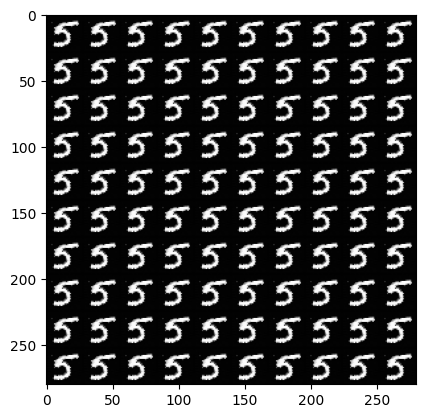

In [ ]:
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)

In [ ]:
fake_img = traj[-1, :1]

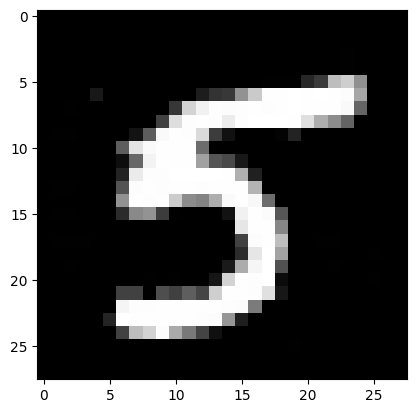

In [ ]:
plt.imshow(fake_img.clip(-1, 1).cpu().numpy().squeeze(0)[0], cmap='gray')

In [ ]:
fake_img_2 = traj[-1, 1000:]

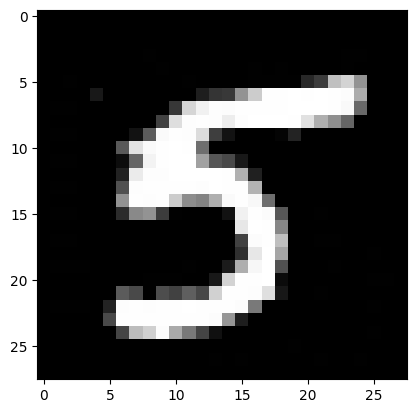

In [ ]:
plt.imshow(fake_img_2.clip(-1, 1).cpu().numpy().squeeze(0)[0], cmap='gray')

In [ ]:
fake_from_sim_noise = traj[-1, :1001].clip(-1, 1).cpu().numpy().squeeze(1).reshape(-1, 28*28)

In [ ]:
fake_from_sim_noise.shape

(1001, 784)

In [ ]:
np.save('/content/fake_from_add_noise.npy', fake_from_sim_noise)

## Генерация новых картинок

In [ ]:
from scipy.stats import norm

In [ ]:
generated_imgs = []
noises_unif = []
noises_norm = []

for i in tqdm(range(42)):
    noise_u = np.random.uniform(size=(1000, 1, 28, 28))
    noise_n = norm.ppf(noise_u).astype(np.float32)
    torch_noise_n = torch.from_numpy(noise_n).to(device)
    with torch.no_grad():
        traj = node.trajectory(
            torch_noise_n,
            t_span=torch.linspace(0, 1, 10, device=device),
        )
    x = traj[-1, :1000]
    x = x.clip(-1, 1).cpu().numpy().squeeze(1).reshape(-1, 28 * 28)
    generated_imgs.append(x)
    noises_unif.append(noise_u)
    noises_norm.append(noise_n)

  0%|          | 0/42 [00:00<?, ?it/s]

In [ ]:
cfm_imgs = np.vstack(generated_imgs)
cfm_noises_unif = np.vstack(noises_unif)
cfm_noises_norm = np.vstack(noises_norm)

In [ ]:
cfm_imgs.shape, cfm_noises_unif.shape, cfm_noises_norm.shape

((42000, 784), (42000, 1, 28, 28), (42000, 1, 28, 28))

In [ ]:
cfm_noises_unif = cfm_noises_unif.reshape(42000, 28*28)
cfm_noises_norm = cfm_noises_norm.reshape(42000, 28*28)

In [ ]:
np.save('/content/cfm_imgs_42000.npy', cfm_imgs)
np.save('/content/cfm_noises_42000_unif.npy', cfm_noises_unif)
np.save('/content/cfm_noises_42000_norm.npy', cfm_noises_norm)

In [ ]:
noise_new = torch.randn(1000, 1, 28, 28, device=device)

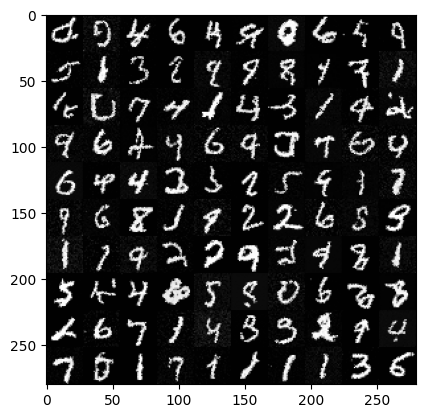

In [ ]:
with torch.no_grad():
    traj = node.trajectory(
        noise_new,
        t_span=torch.linspace(0, 1, 10, device=device),
    )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)

In [ ]:
# fake = traj[-1, :1000]
# fake = fake.clip(-1, 1).cpu().numpy().squeeze(1).reshape(-1, 28 * 28)
# fake.shape

(1000, 784)

In [ ]:
# noise = noise.cpu().numpy().squeeze(1).reshape(-1, 28 * 28)
# noise.shape

(1000, 784)

In [ ]:
fake_new = traj[-1, :1000]
fake_new = fake_new.clip(-1, 1).cpu().numpy().squeeze(1).reshape(-1, 28 * 28)
noise_new = noise_new.cpu().numpy().squeeze(1).reshape(-1, 28 * 28)

In [ ]:
# stack fake and fake_new n_times
fake = np.vstack([fake, fake_new])
noise = np.vstack([noise, noise_new])

In [ ]:
fake.shape, noise.shape

((3000, 784), (3000, 784))

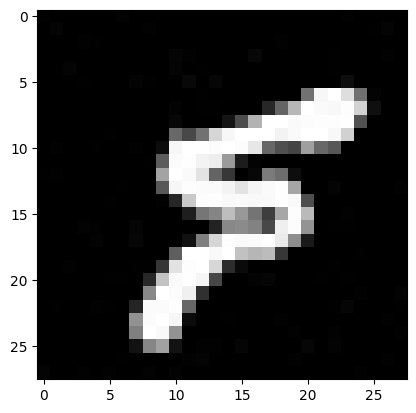

In [ ]:
plt.imshow(fake[2410].reshape(28, 28), cmap='gray')

In [ ]:
np.save('/content/cfm_imgs_3000_newnew.npy', fake)
np.save('/content/cfm_imgs_3000_noise_newnew.npy', noise)